#Statistics

# **Probability Distribution Function**

## 1) PMF - Probability Mass Function
Dice Rolling Experiment

In [1]:
import pandas as pd
import random

In [2]:
L = []
for i in range(10000):
  L.append(random.randint(1,6))

In [3]:
len(L) # so now L has 1000 random values from 1 to 6

10000

In [4]:
#In first when rooled the dice we got this all numbers
L[:5]

[1, 5, 4, 4, 5]

In [5]:
#Converting L to a series
pd.Series(L).value_counts()

,count
5,1702
2,1697
4,1681
1,1668
3,1652
6,1600


In [6]:
#Probability of each of the outcome
S = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [7]:
S

,count
1,0.1668
2,0.1697
3,0.1652
4,0.1681
5,0.1702
6,0.1600


<Axes: >

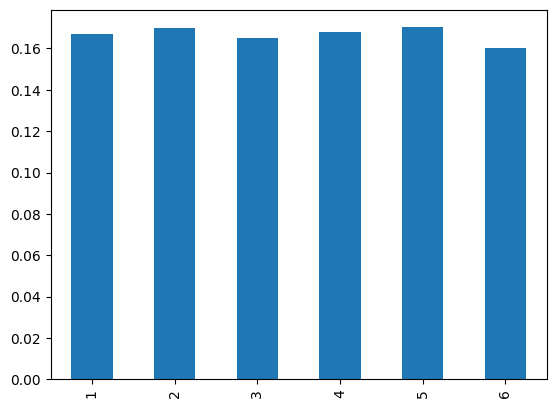

In [8]:
#Plotting a graph to see the PMF
S.plot(kind='bar')

Rolling two dice

In [9]:
L = []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)
  #appending sum of the two dice outcome
  L.append(a+b)

In [10]:
len(L)

10000

In [11]:
L[:5]

[6, 7, 8, 6, 9]

In [12]:
#Converting it into series
S = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

In [13]:
#probability I got
S

,count
2,0.0270
3,0.0606
4,0.0835
5,0.1130
6,0.1360
7,0.1649
8,0.1397
9,0.1079
10,0.0838
11,0.0532


<Axes: >

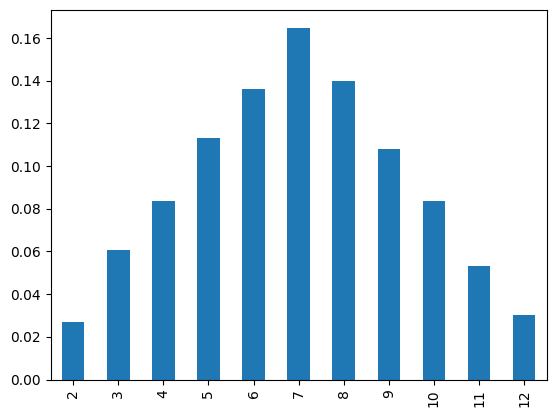

In [14]:
#Plotting PMF
S.plot(kind="bar")

# **CDF from PMF**

In [23]:
import numpy as np

np.cumsum(S)

,count
2,0.0270
3,0.0876
4,0.1711
5,0.2841
6,0.4201
7,0.5850
8,0.7247
9,0.8326
10,0.9164
11,0.9696


<Axes: >

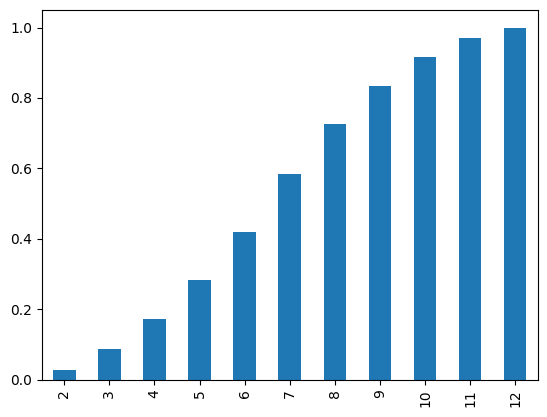

In [24]:
np.cumsum(S).plot(kind="bar")

This graph is basically saying the Cumulative Distribution. if i see 9 then its Probability around 90%.

Probability of 9 or less than 9 possibility is 90%.  

# **Probability Density Function**

## Parametric Destiny Estimation

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

In [26]:
#I will generate normal distribution data which mean is 50 and std is 5.this are the population parameters.
sample = normal(loc = 50,scale = 5, size = 1000)

In [27]:
sample

array([54.04644035, 49.90104625, 58.30661161, 50.85417431, 51.03531221,
       49.9126641 , 49.75811113, 50.15070737, 47.82563872, 44.0453091 ,
       49.53192616, 48.29297808, 42.94450352, 55.40864787, 54.42920799,
       49.00534593, 51.34584919, 56.35973649, 57.75657429, 48.85285322,
       44.24567882, 56.0480296 , 41.10699118, 48.76145346, 50.00388127,
       45.1250311 , 47.70901769, 46.03110003, 43.80809305, 61.31692708,
       46.86750683, 41.72190106, 55.09798962, 44.73942568, 52.26750642,
       50.32609567, 42.37320949, 47.75914661, 49.77434472, 49.27671202,
       53.82634671, 49.64870504, 53.15866082, 49.88172096, 55.04608037,
       45.84414266, 53.39196343, 50.53549865, 53.65442729, 43.15094422,
       48.89692806, 50.37351353, 53.68580064, 48.25988771, 46.4035225 ,
       45.62335028, 48.90207283, 51.65006427, 43.70256258, 48.40125052,
       51.91154921, 42.76358656, 48.11114262, 45.96679723, 51.3578664 ,
       46.85553408, 50.70352929, 43.04462049, 50.31385678, 58.62

In [28]:
sample.mean()

np.float64(50.00929048183136)

(array([  6.,  17.,  60., 151., 250., 229., 166.,  90.,  23.,   8.]),
 array([33.8075868 , 36.98644175, 40.16529671, 43.34415167, 46.52300662,
        49.70186158, 52.88071654, 56.05957149, 59.23842645, 62.41728141,
        65.59613636]),
 <BarContainer object of 10 artists>)

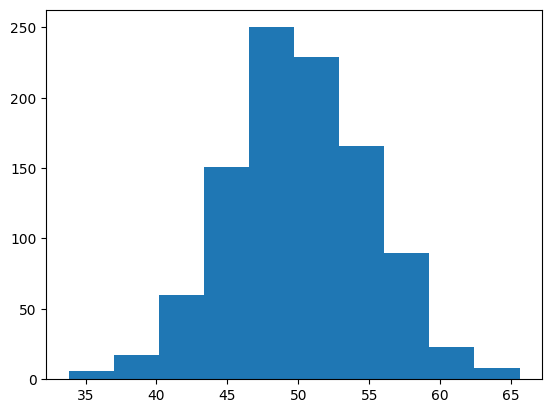

In [29]:
#plotting histogram to understand the distribution of the data.
plt.hist(sample,bins=10)

In [30]:
#calculate sample mean and sample standard deviation through population
sample_mean = sample.mean()
sample_std = sample.std()

In [32]:
#fit the distribution with above parameters.
from scipy.stats import norm

dist = norm(sample_mean,sample_std)

In [33]:
values = np.linspace(sample.min(),sample.max(),100)

In [34]:
probability_density = [dist.pdf(value) for value in values]

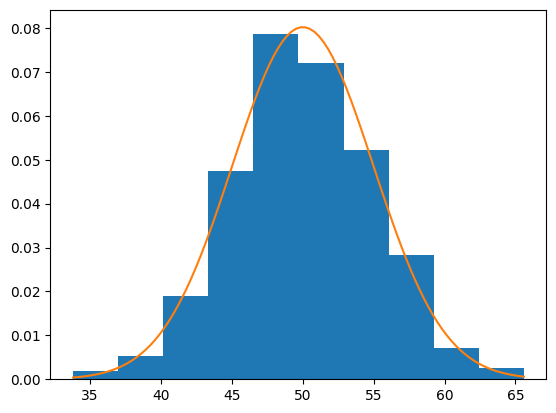

In [37]:
#plot histogram and pdf
plt.hist(sample,bins=10, density = True)
plt.plot(values,probability_density)

/tmp/ipykernel_547/19883092.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

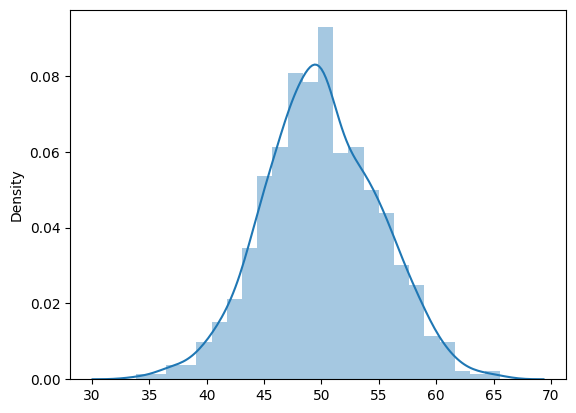

In [38]:
#using seaborn
import seaborn as sns

sns.distplot(sample)

## Non Parametric Destiny Estimation(KDE)

In [39]:
#generate a sample
sample1 = normal(loc=20, scale=5,size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1,sample2))

In [40]:
sample

array([22.66539375, 21.36766862, 25.70228148, 10.8930893 , 26.81094504,
       19.89148609, 26.91025725, 12.62435915, 14.70889184, 20.55267552,
       19.19708891, 20.19847022, 12.2718589 , 11.44633181, 15.97135976,
       12.29222193, 18.32155603, 23.89444158, 28.01252307, 25.77857423,
       19.30525111,  8.50072785, 22.99135895, 32.4877467 , 22.05212478,
       19.25974668, 16.08448875, 22.33166305, 19.87534017, 16.80583193,
       14.60917521, 17.27219113, 17.75613478, 20.83328509, 21.84404404,
       18.52381032, 18.25146326, 15.55051555, 19.72279585, 19.19624025,
       20.68024804, 16.52738732, 29.44190485, 16.09513384, 17.36903515,
       15.04286341, 22.10062464, 17.96660949, 22.64524152, 26.8742311 ,
       23.86451996, 26.30618766, 19.38929287, 24.23216428, 17.33895613,
       16.90268177, 22.06852421, 12.11986846, 27.93489792, 11.72677629,
       25.78621383, 23.09673878, 23.10362603, 21.22600942, 28.31368024,
       14.50051746, 17.79403405, 17.57622048, 23.740095  , 16.27

(array([ 1.,  0.,  3.,  1.,  2.,  4., 10.,  3.,  8., 17., 21., 23., 29.,
        28., 18., 19., 22., 14., 25., 17., 16.,  9., 12., 14., 15.,  9.,
        16., 28., 32., 44., 49., 62., 62., 51., 61., 58., 45., 28., 36.,
        21., 21., 14., 12.,  9.,  2.,  2.,  4.,  1.,  1.,  1.]),
 array([ 5.00537511,  6.05127612,  7.09717713,  8.14307813,  9.18897914,
        10.23488015, 11.28078115, 12.32668216, 13.37258317, 14.41848417,
        15.46438518, 16.51028619, 17.55618719, 18.6020882 , 19.64798921,
        20.69389021, 21.73979122, 22.78569223, 23.83159323, 24.87749424,
        25.92339525, 26.96929626, 28.01519726, 29.06109827, 30.10699928,
        31.15290028, 32.19880129, 33.2447023 , 34.2906033 , 35.33650431,
        36.38240532, 37.42830632, 38.47420733, 39.52010834, 40.56600934,
        41.61191035, 42.65781136, 43.70371236, 44.74961337, 45.79551438,
        46.84141539, 47.88731639, 48.9332174 , 49.97911841, 51.02501941,
        52.07092042, 53.11682143, 54.16272243, 55.20862344,

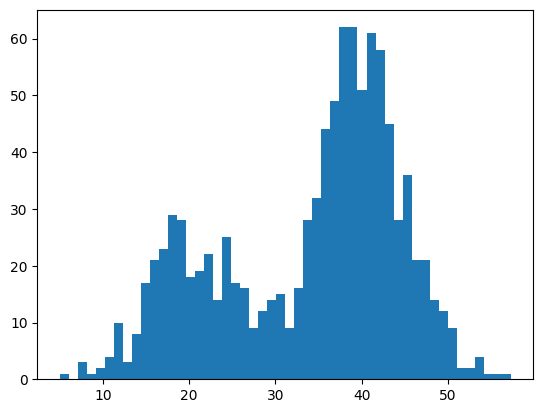

In [41]:
#plot histogram bins=50
plt.hist(sample,bins=50)

In [43]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=5, kernel = 'gaussian')

#convert data to a 2D array because ML algo does not work with 1D data.
sample = sample.reshape((len(sample),1))

model.fit(sample)

KernelDensity(bandwidth=5)

In [46]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values),1))

score_samples(values) returns the log-density estimate of the input samples values. This is because the score_samples() method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

In [47]:
probability_density = model.score_samples(values)
probability_density = np.exp(probability_density) #to convert it into actual probability from logarithm.

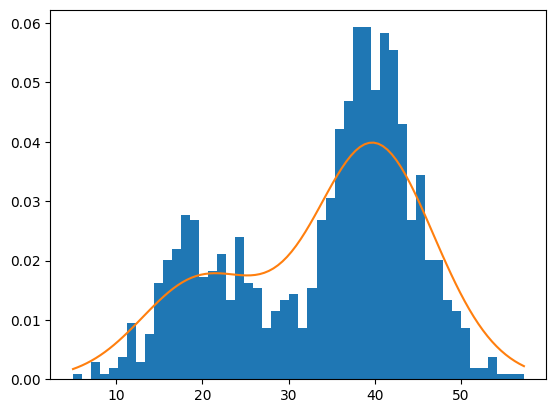

In [48]:
plt.hist(sample,bins=50,density=True)
plt.plot(values[:],probability_density)
plt.show()

<Axes: ylabel='Density'>

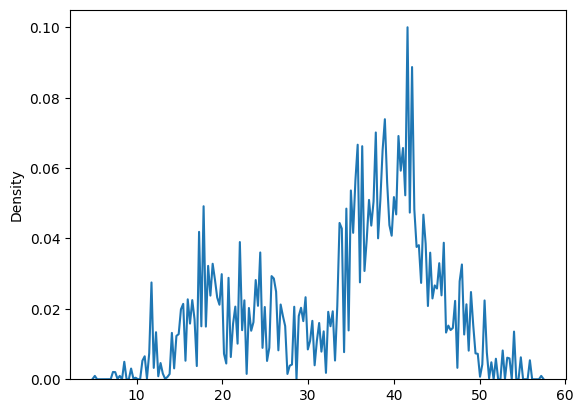

In [49]:
#we can adjust the bandwidth means standard deviation its like hyperparameter.

sns.kdeplot(sample.reshape(1000),bw_adjust=0.02)

<Axes: ylabel='Density'>

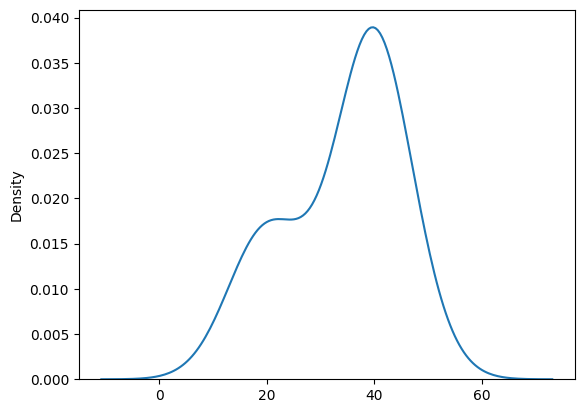

In [51]:
sns.kdeplot(sample.reshape(1000),bw_adjust=2)

## **Binomial distribution**

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
n = 10 #number of trials
p = 0.1 #probability of success
size = 1000 #number of samples to generate

binomial_dist = np.random.binomial(n,p,size)
binomial_dist

array([2, 1, 0, 0, 2, 1, 1, 1, 0, 3, 2, 2, 2, 0, 0, 0, 1, 1, 2, 1, 2, 0,
       0, 2, 1, 1, 2, 2, 3, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 1, 1, 2,
       0, 0, 1, 0, 1, 2, 3, 0, 1, 0, 1, 0, 1, 1, 1, 3, 2, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 2, 2, 3, 0, 0, 2, 2, 2, 2, 1, 3, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 3, 0, 1, 0, 1, 0, 2, 2, 1, 1, 0, 0, 2, 0, 0, 0, 2, 2, 0,
       2, 0, 2, 0, 3, 2, 1, 0, 3, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 1, 0, 2,
       0, 0, 2, 1, 1, 1, 1, 1, 4, 3, 0, 0, 2, 0, 1, 0, 0, 1, 1, 2, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 2, 2, 1, 1, 1, 3, 2, 1, 0, 0, 3, 0, 2, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 0, 3, 1, 1, 1,
       3, 1, 0, 2, 0, 1, 0, 2, 1, 1, 4, 1, 1, 0, 1, 1, 0, 1, 0, 1, 2, 0,
       1, 1, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 2, 2, 2, 1, 2,
       1, 0, 1, 1, 1, 2, 2, 0, 1, 0, 3, 1, 1, 4, 0, 0, 0, 0, 3, 1, 1, 3,
       2, 1, 4, 0, 2, 0, 1, 1, 1, 3, 2, 1, 2, 1, 0, 0, 0, 0, 1, 2, 3, 1,
       1, 2, 0, 0, 3, 0, 3, 2, 0, 3, 3, 1, 1, 0, 0,

In [17]:
binomial_dist.shape

(1000,)

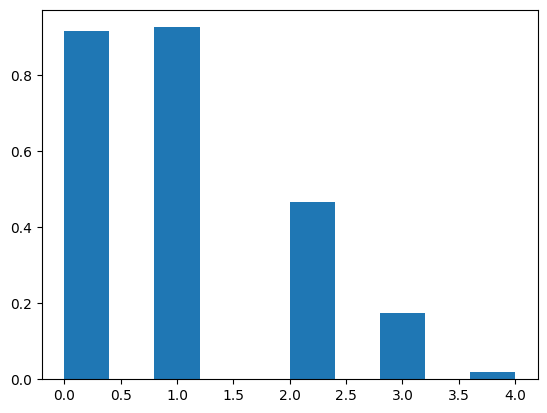

In [18]:
plt.hist(binomial_dist,density=True)
plt.show()

In [19]:
n = 10 #number of trials
p = 0.5 #probability of success
size = 1000 #number of samples to generate

binomial_dist = np.random.binomial(n,p,size)
binomial_dist

array([3, 6, 5, 6, 5, 5, 2, 5, 4, 8, 3, 6, 6, 6, 7, 6, 3, 7, 5, 5, 8, 4,
       6, 4, 4, 5, 4, 8, 4, 5, 4, 5, 7, 8, 6, 6, 3, 5, 7, 4, 6, 5, 8, 3,
       7, 5, 5, 4, 3, 5, 3, 6, 8, 5, 7, 4, 8, 7, 8, 4, 6, 4, 7, 4, 5, 7,
       5, 6, 4, 7, 3, 5, 3, 7, 4, 5, 6, 3, 4, 6, 4, 5, 3, 3, 6, 6, 6, 4,
       4, 5, 4, 8, 5, 4, 5, 4, 4, 5, 4, 5, 4, 8, 4, 7, 4, 4, 6, 7, 5, 6,
       5, 7, 2, 4, 8, 6, 4, 4, 3, 6, 5, 5, 6, 5, 5, 3, 4, 5, 6, 5, 6, 3,
       7, 5, 5, 4, 5, 5, 5, 6, 4, 5, 6, 4, 6, 3, 5, 5, 5, 4, 6, 5, 5, 6,
       4, 3, 4, 7, 4, 7, 6, 5, 7, 4, 4, 4, 6, 5, 6, 2, 5, 3, 5, 5, 6, 3,
       4, 5, 1, 6, 5, 2, 4, 3, 5, 1, 3, 5, 5, 8, 6, 5, 6, 6, 4, 3, 6, 6,
       5, 4, 8, 6, 4, 4, 4, 6, 5, 5, 7, 6, 6, 4, 5, 6, 7, 3, 5, 5, 4, 6,
       4, 4, 5, 6, 2, 5, 7, 5, 8, 2, 4, 5, 7, 6, 7, 3, 6, 5, 5, 5, 6, 4,
       5, 6, 3, 5, 4, 4, 6, 5, 4, 5, 7, 5, 5, 4, 4, 5, 6, 1, 4, 7, 3, 5,
       5, 5, 4, 8, 6, 5, 1, 6, 6, 8, 6, 5, 6, 4, 6, 2, 3, 9, 3, 3, 2, 5,
       4, 4, 5, 5, 3, 8, 3, 6, 2, 2, 4, 5, 5, 6, 4,

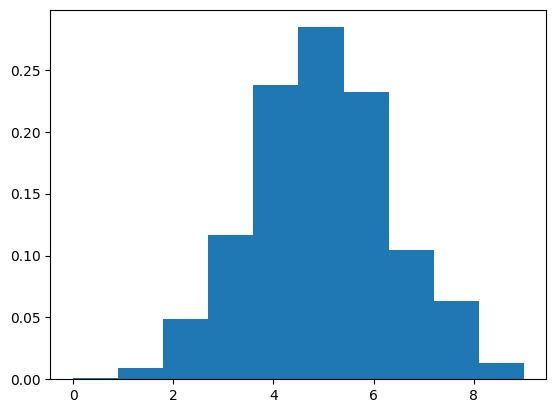

In [20]:
plt.hist(binomial_dist,density=True)
plt.show()

In [21]:
n = 10 #number of trials
p = 0.7 #probability of success
size = 1000 #number of samples to generate

binomial_dist = np.random.binomial(n,p,size)
binomial_dist # first 10 toss a 6 ta besi bar eseche. 2nd bar jokhon 10 bar korlam tokhon 8 ta besi bar eseche.

array([ 5,  9,  9,  5,  7,  6,  7,  7,  8,  4,  9,  8,  7,  7,  7,  8,  8,
        6,  9,  7,  7,  8,  5,  6,  4,  7,  8,  7,  6,  5,  8,  6,  6,  8,
        5,  7,  7,  8,  5,  6,  6,  8,  7,  7,  8,  7,  9,  8,  7,  7, 10,
        7,  5,  8,  8,  6,  8,  8,  7,  7,  7,  9,  5,  7,  8,  6,  7,  8,
        8,  7,  8,  7,  5,  9,  6,  7,  7,  8,  7,  6,  8,  6,  9,  9,  8,
        8,  5,  6,  8,  8,  8,  7,  5,  6,  6,  5,  8,  9,  6,  8,  7,  6,
        6,  8,  2,  5,  7,  8,  9,  4,  9,  7,  7,  7,  9, 10,  8,  6,  5,
        8,  7,  7,  6,  6,  6,  9,  5,  6,  7,  6,  7,  9,  8,  6,  7,  8,
        8,  7,  4,  6,  7, 10,  4,  7,  9,  8,  9,  6,  6,  8,  6,  9,  7,
        8,  9,  7,  6,  8,  7,  8,  8,  5,  4,  6,  5, 10,  7,  6,  7,  5,
        4,  6,  6,  7,  6,  8,  9,  9,  8,  8,  5,  9,  7,  2,  9,  8,  9,
        8,  6,  7,  8,  6,  9,  8,  7,  2,  6,  6,  3,  6,  6,  4,  7,  9,
        6,  8,  8,  7,  6,  8,  6,  9,  6,  7,  7,  5,  4,  4,  7,  7,  7,
        8,  8,  8,  8,  8

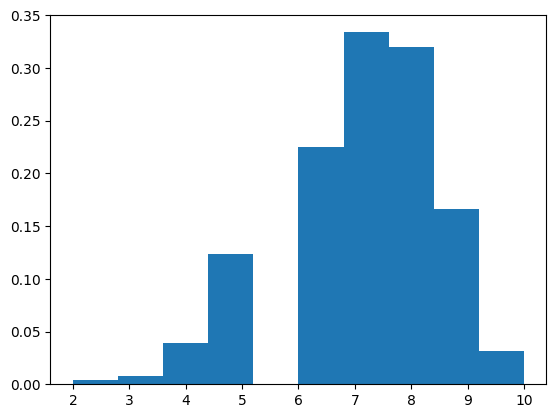

In [22]:
plt.hist(binomial_dist,density=True)
plt.show()